<a href="https://colab.research.google.com/github/mohammedqasim352002/NorthStar-Analytics/blob/main/R_with_SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
install.packages(c("sqldf", "dplyr", "ggplot2", "readr", "lubridate"))

library(sqldf)
library(dplyr)
library(ggplot2)
library(readr)
library(lubridate)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [24]:
# Increase timeout (important for GitHub loading)
options(timeout = 600)

# Load required library
library(readr)

# Base GitHub raw URL
base_url <- "https://raw.githubusercontent.com/mohammedqasim352002/NorthStar-Analytics/main/data/"

# Load all datasets (clean output)
app_events <- read_csv(paste0(base_url, "app_events.csv"), show_col_types = FALSE)
complaints <- read_csv(paste0(base_url, "complaints.csv"), show_col_types = FALSE)
customers  <- read_csv(paste0(base_url, "customers.csv"), show_col_types = FALSE)
deliveries <- read_csv(paste0(base_url, "deliveries.csv"), show_col_types = FALSE)
drivers    <- read_csv(paste0(base_url, "drivers.csv"), show_col_types = FALSE)
hubs       <- read_csv(paste0(base_url, "hubs.csv"), show_col_types = FALSE)
incidents  <- read_csv(paste0(base_url, "incidents.csv"), show_col_types = FALSE)
orders     <- read_csv(paste0(base_url, "orders.csv"), show_col_types = FALSE)
vehicles   <- read_csv(paste0(base_url, "vehicles.csv"), show_col_types = FALSE)

# Confirmation message
cat("All CSV files loaded successfully from GitHub.\n")

All CSV files loaded successfully from GitHub.


In [25]:
normalise_zone <- function(z) {
  z <- trimws(toupper(z))
  z <- case_when(
    z %in% c("NORTH", "N")               ~ "North",
    z %in% c("SOUTH", "S")               ~ "South",
    z %in% c("EAST")                     ~ "East",
    z %in% c("WEST")                     ~ "West",
    z %in% c("CENTRAL", "CTR", "CENTRE") ~ "Central",
    z %in% c("AIRPORT")                  ~ "Airport",
    z %in% c("RIVERSIDE")                ~ "Riverside",
    TRUE                                 ~ z
  )
  return(z)
}

customers$home_zone        <- normalise_zone(customers$home_zone)
drivers$base_zone          <- normalise_zone(drivers$base_zone)
vehicles$assigned_zone     <- normalise_zone(vehicles$assigned_zone)
orders$pickup_zone         <- normalise_zone(orders$pickup_zone)
orders$dropoff_zone        <- normalise_zone(orders$dropoff_zone)
app_events$zone_context    <- normalise_zone(app_events$zone_context)
hubs$zone                  <- normalise_zone(hubs$zone)

cat("Zone normalisation complete.\n")

Zone normalisation complete.


In [26]:
# training_score: median imputation (numeric, not financially sensitive)
drivers$training_score[is.na(drivers$training_score)] <-
  median(drivers$training_score, na.rm = TRUE)

# battery_health_pct: median imputation
vehicles$battery_health_pct[is.na(vehicles$battery_health_pct)] <-
  median(vehicles$battery_health_pct, na.rm = TRUE)

# customer_rating_post_delivery: median imputation
deliveries$customer_rating_post_delivery[is.na(deliveries$customer_rating_post_delivery)] <-
  median(deliveries$customer_rating_post_delivery, na.rm = TRUE)

# compensation_amount: flag as NA (absence is meaningful — unresolved complaints)
# resolved_hours: flag as NA (missing = unresolved incident, meaningful)
# preferred_channel in customers: leave as NA (not used in SQL queries)

cat("Missing value handling complete.\n")
cat("Drivers training_score NAs remaining:", sum(is.na(drivers$training_score)), "\n")
cat("Vehicles battery_health_pct NAs remaining:", sum(is.na(vehicles$battery_health_pct)), "\n")
cat("Deliveries rating NAs remaining:", sum(is.na(deliveries$customer_rating_post_delivery)), "\n")

Missing value handling complete.
Drivers training_score NAs remaining: 0 
Vehicles battery_health_pct NAs remaining: 0 
Deliveries rating NAs remaining: 0 


In [27]:
library(lubridate)
library(dplyr)

# Convert to datetime safely (no warnings)
deliveries$dispatch_time <- ymd_hms(deliveries$dispatch_time, quiet = TRUE)
deliveries$delivery_completed_at <- ymd_hms(deliveries$delivery_completed_at, quiet = TRUE)

# Flag anomalies (including NA-safe condition)
deliveries <- deliveries %>%
  mutate(
    timestamp_anomaly = ifelse(
      is.na(dispatch_time) | is.na(delivery_completed_at),
      TRUE,
      delivery_completed_at < dispatch_time
    )
  )

# Count anomalies
anomaly_count <- sum(deliveries$timestamp_anomaly, na.rm = TRUE)
anomaly_pct   <- round(anomaly_count / nrow(deliveries) * 100, 2)

# Print results
cat("Timestamp anomalies (completed before dispatched or invalid timestamps):", anomaly_count, "\n")
cat("Percentage of delivery records affected:", anomaly_pct, "%\n")
cat("These records are flagged and excluded from duration analysis.\n")

# Clean dataset (remove anomalies)
deliveries_clean <- deliveries %>%
  filter(!timestamp_anomaly)

Timestamp anomalies (completed before dispatched or invalid timestamps): 84 
Percentage of delivery records affected: 8.84 %
These records are flagged and excluded from duration analysis.


In [28]:
q1 <- sqldf("
  SELECT
    pickup_zone,
    COUNT(order_id)          AS total_orders,
    ROUND(AVG(order_value), 2) AS avg_order_value,
    ROUND(SUM(order_value), 2) AS total_revenue
  FROM orders
  GROUP BY pickup_zone
  ORDER BY total_orders DESC
")

print(q1)

  pickup_zone total_orders avg_order_value total_revenue
1     Central          238           88.45      21051.30
2        East          207           91.77      18997.29
3       South          181           90.58      16395.88
4       North          174           91.03      15839.55
5        West          155           88.27      13682.42
6   Riverside          151           85.34      12886.45
7     Airport          144          103.89      14960.26


In [29]:
q2 <- sqldf("
  SELECT
    o.service_type,
    COUNT(DISTINCT o.order_id)     AS total_orders,
    COUNT(DISTINCT c.complaint_id) AS total_complaints,
    ROUND(
      COUNT(DISTINCT c.complaint_id) * 100.0 / COUNT(DISTINCT o.order_id),
      2
    ) AS complaint_rate_pct
  FROM orders o
  LEFT JOIN complaints c ON o.order_id = c.order_id
  GROUP BY o.service_type
  ORDER BY complaint_rate_pct DESC
")

print(q2)

  service_type total_orders total_complaints complaint_rate_pct
1       Retail          297               83              27.95
2      Medical          139               37              26.62
3       Parcel          308               77              25.00
4    Passenger          341               84              24.63
5     Business          165               39              23.64


In [30]:
q3 <- sqldf("
  SELECT
    d.hub_id,
    h.hub_name,
    h.zone,
    h.hub_type,
    h.capacity_score,
    COUNT(d.delivery_id)                                          AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed_count,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed_count,
    ROUND(
      (SUM(CASE WHEN d.delivery_status IN ('Failed','Delayed') THEN 1 ELSE 0 END) * 100.0)
      / COUNT(d.delivery_id), 2
    ) AS failure_rate_pct
  FROM deliveries d
  LEFT JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY d.hub_id, h.hub_name, h.zone, h.hub_type, h.capacity_score
  ORDER BY failure_rate_pct DESC
")

print(q3)

  hub_id       hub_name      zone  hub_type capacity_score total_deliveries
1    H05   Central Core   Central   Control             88              115
2    H06    Airport Hub   Airport  Dispatch             71              104
3    H08  Midtown Relay   Central  Charging             63              128
4    H04      West Gate      West  Dispatch             69              127
5    H02     South Link     South  Dispatch             78              106
6    H07  Riverside Hub Riverside Warehouse             66              115
7    H01 North Exchange     North  Dispatch             82              136
8    H03      East Dock      East Warehouse             74              119
  failed_count delayed_count failure_rate_pct
1           23            25            41.74
2           15            27            40.38
3           26            22            37.50
4           16            28            34.65
5           10            26            33.96
6           14            25            

In [31]:
q4 <- sqldf("
  SELECT
    employment_type,
    COUNT(driver_id)                   AS driver_count,
    ROUND(AVG(driver_rating), 2)       AS avg_rating,
    ROUND(AVG(training_score), 2)      AS avg_training_score,
    ROUND(MIN(driver_rating), 2)       AS min_rating,
    ROUND(MAX(driver_rating), 2)       AS max_rating
  FROM drivers
  WHERE active_flag = 1
  GROUP BY employment_type
  ORDER BY avg_rating DESC
")

print(q4)

  employment_type driver_count avg_rating avg_training_score min_rating
1        PartTime           36       4.22              73.79       3.35
2        FullTime          105       4.17              75.56       3.15
3        Contract           20       4.09              73.53       3.32
  max_rating
1       5.00
2       5.00
3       4.97


In [32]:
q5 <- sqldf("
  SELECT
    channel,
    severity,
    COUNT(complaint_id)                        AS total_complaints,
    ROUND(AVG(resolution_days), 2)             AS avg_resolution_days,
    ROUND(AVG(compensation_amount), 2)         AS avg_compensation,
    ROUND(SUM(compensation_amount), 2)         AS total_compensation,
    SUM(CASE WHEN status = 'Open'     THEN 1 ELSE 0 END) AS open_count,
    SUM(CASE WHEN status = 'Escalated' THEN 1 ELSE 0 END) AS escalated_count
  FROM complaints
  GROUP BY channel, severity
  ORDER BY severity, avg_resolution_days DESC
")

print(q5)

   channel severity total_complaints avg_resolution_days avg_compensation
1      App     High               20               14.55            39.25
2    Phone     High               21               14.05            32.91
3    Email     High               21               11.95            43.12
4  Chatbot     High               15               11.53            40.76
5    Phone      Low               14                7.36            10.53
6    Email      Low               16                6.63             7.91
7      App      Low               21                6.52             8.51
8  Chatbot      Low               20                6.00             9.46
9      App   Medium               56                6.80            18.03
10 Chatbot   Medium               32                6.63            17.82
11   Phone   Medium               57                5.91            17.99
12   Email   Medium               27                4.85            14.09
   total_compensation open_count escal

In [33]:
q6 <- sqldf("
  SELECT
    i.incident_type,
    i.severity,
    h.zone,
    h.hub_name,
    COUNT(i.incident_id)                AS incident_count,
    ROUND(AVG(i.resolved_hours), 2)     AS avg_resolved_hours,
    SUM(CASE WHEN i.resolution_status IN ('Open','Escalated','PendingVendor')
             THEN 1 ELSE 0 END)         AS unresolved_count
  FROM incidents i
  LEFT JOIN deliveries d ON i.delivery_id = d.delivery_id
  LEFT JOIN hubs h       ON d.hub_id      = h.hub_id
  GROUP BY i.incident_type, i.severity, h.zone, h.hub_name
  ORDER BY incident_count DESC
")

print(q6)

       incident_type severity      zone       hub_name incident_count
1     RouteDeviation      Low      East      East Dock              6
2       AppSyncError   Medium   Central  Midtown Relay              5
3       BatteryAlert   Medium Riverside  Riverside Hub              5
4     CustomerNoShow     High     South     South Link              5
5       VehicleFault     High Riverside  Riverside Hub              5
6       VehicleFault   Medium     North North Exchange              5
7       BatteryAlert   Medium   Central   Central Core              4
8       ProofMissing     High   Central   Central Core              4
9       ProofMissing   Medium      West      West Gate              4
10    RouteDeviation      Low     North North Exchange              4
11  TemperatureIssue   Medium   Central   Central Core              4
12      VehicleFault   Medium   Central  Midtown Relay              4
13      VehicleFault   Medium      West      West Gate              4
14      BatteryAlert

In [34]:
q7 <- sqldf("
  SELECT
    home_zone,
    customer_type,
    account_status,
    COUNT(customer_id)                    AS customer_count,
    ROUND(AVG(loyalty_score), 2)          AS avg_loyalty,
    ROUND(AVG(app_engagement_score), 2)   AS avg_engagement,
    SUM(CASE WHEN account_status = 'Dormant' THEN 1 ELSE 0 END) AS dormant_count
  FROM customers
  GROUP BY home_zone, customer_type, account_status
  ORDER BY avg_loyalty DESC
")

print(q7)

   home_zone customer_type account_status customer_count avg_loyalty
1  Riverside           SME      Suspended              1       95.20
2       East    Enterprise      Suspended              1       80.30
3    Central    Enterprise        Dormant              2       79.50
4  Riverside    Enterprise         Active              4       74.28
5      South      Consumer      Suspended              3       72.13
6    Airport           SME        Dormant              2       70.10
7      North    Enterprise        Dormant              1       67.60
8       East      Consumer      Suspended              3       66.47
9    Airport      Consumer        Dormant              5       64.43
10   Airport    Enterprise      Suspended              1       63.70
11 Riverside      Consumer      Suspended              3       63.60
12      West           SME         Active             10       63.44
13   Central      Consumer         Active             75       62.54
14     North      Consumer        

In [35]:
q8 <- sqldf("
  SELECT
    delivery_status,
    COUNT(delivery_id)                          AS delivery_count,
    ROUND(AVG(manual_route_override_count), 3)  AS avg_overrides,
    ROUND(AVG(route_distance_km), 2)            AS avg_distance_km,
    ROUND(AVG(fuel_or_charge_cost), 2)          AS avg_fuel_cost,
    ROUND(AVG(customer_rating_post_delivery), 2) AS avg_customer_rating
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY avg_overrides DESC
")

print(q8)

  delivery_status delivery_count avg_overrides avg_distance_km avg_fuel_cost
1         Delayed            202         1.074           14.67         13.14
2          Failed            132         1.038           13.37         13.15
3          OnTime            616         0.920           13.78         12.68
  avg_customer_rating
1                3.14
2                3.06
3                4.28


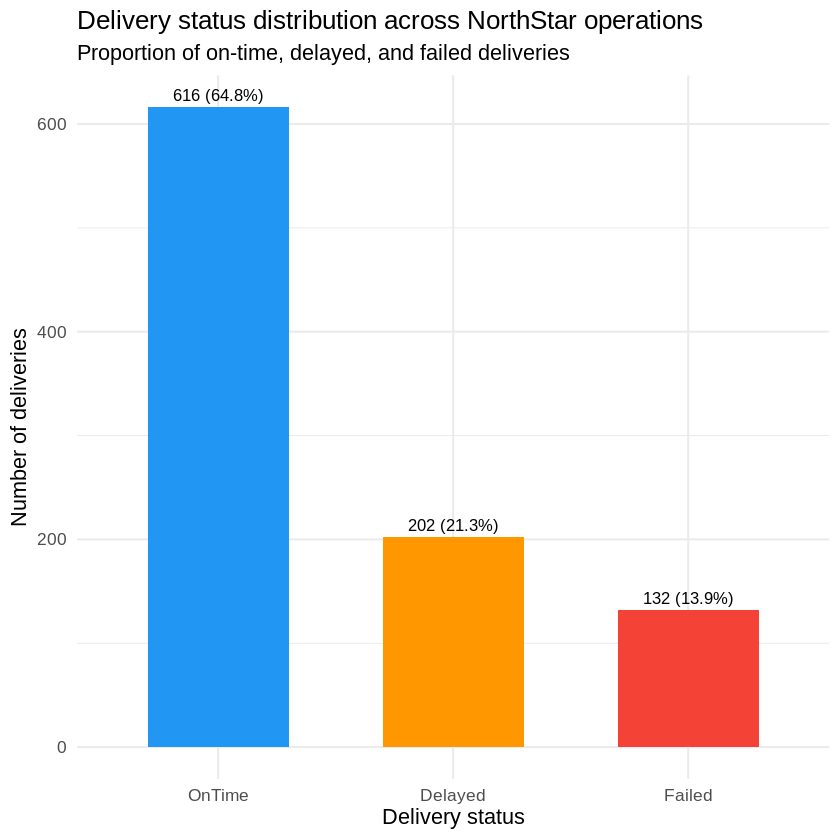

In [36]:
delivery_status_counts <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(count = n()) %>%
  mutate(pct = round(count / sum(count) * 100, 1))

ggplot(delivery_status_counts, aes(x = reorder(delivery_status, -count),
                                    y = count,
                                    fill = delivery_status)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = paste0(count, " (", pct, "%)")),
            vjust = -0.5, size = 3.5) +
  scale_fill_manual(values = c("OnTime"  = "#2196F3",
                                "Delayed" = "#FF9800",
                                "Failed"  = "#F44336")) +
  labs(
    title    = "Delivery status distribution across NorthStar operations",
    subtitle = "Proportion of on-time, delayed, and failed deliveries",
    x        = "Delivery status",
    y        = "Number of deliveries",
    fill     = "Status"
  ) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "none")

`geom_smooth()` using formula = 'y ~ x'


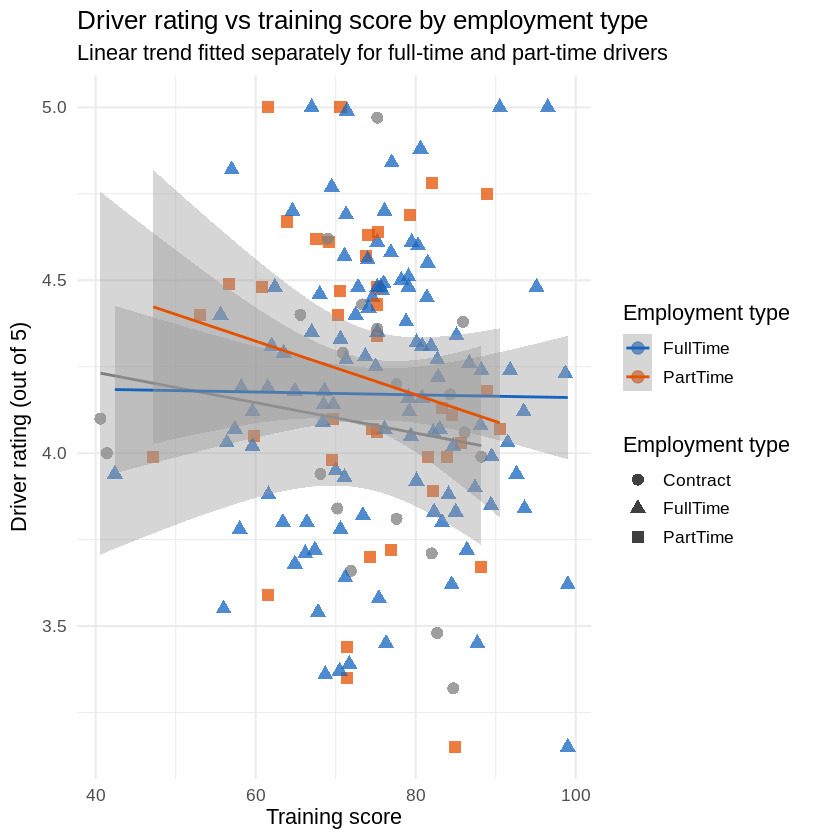

In [37]:
ggplot(drivers, aes(x = training_score,
                    y = driver_rating,
                    colour = employment_type,
                    shape  = employment_type)) +
  geom_point(size = 3, alpha = 0.75) +
  geom_smooth(method = "lm", se = TRUE, linewidth = 0.8) +
  scale_colour_manual(values = c("FullTime" = "#1565C0", "PartTime" = "#E65100")) +
  labs(
    title    = "Driver rating vs training score by employment type",
    subtitle = "Linear trend fitted separately for full-time and part-time drivers",
    x        = "Training score",
    y        = "Driver rating (out of 5)",
    colour   = "Employment type",
    shape    = "Employment type"
  ) +
  theme_minimal(base_size = 13)

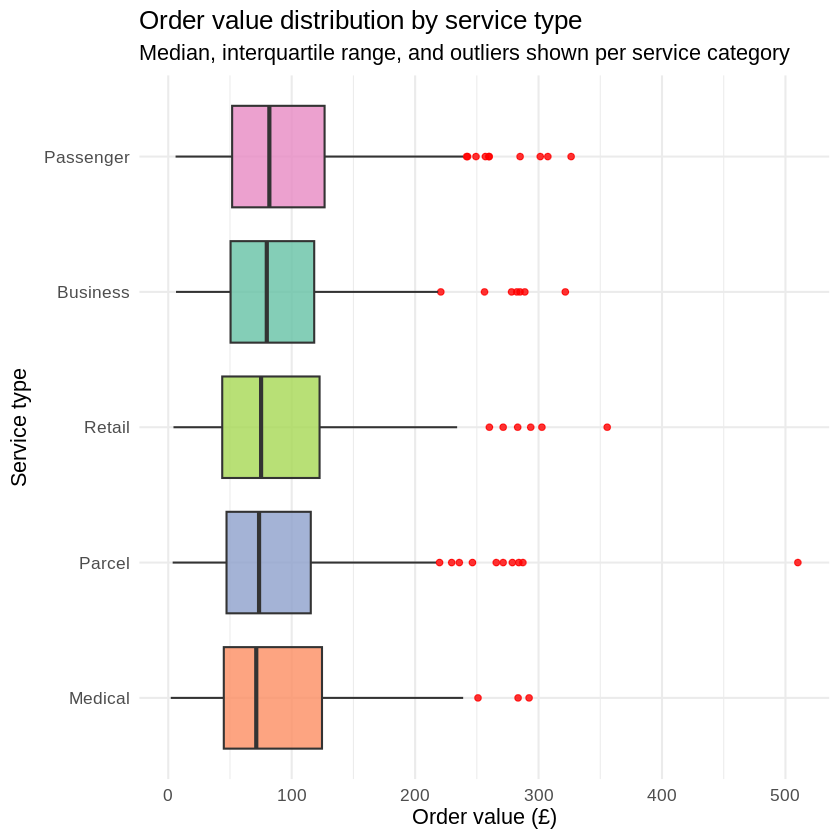

In [38]:
ggplot(orders, aes(x = reorder(service_type, order_value, FUN = median),
                   y = order_value,
                   fill = service_type)) +
  geom_boxplot(outlier.colour = "red", outlier.size = 1.5, alpha = 0.8) +
  coord_flip() +
  scale_fill_brewer(palette = "Set2") +
  labs(
    title    = "Order value distribution by service type",
    subtitle = "Median, interquartile range, and outliers shown per service category",
    x        = "Service type",
    y        = "Order value (£)",
    fill     = "Service type"
  ) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "none")

In [39]:
resolution_summary <- complaints %>%
  group_by(severity) %>%
  summarise(
    complaint_count   = n(),
    mean_resolution   = round(mean(resolution_days, na.rm = TRUE), 2),
    median_resolution = round(median(resolution_days, na.rm = TRUE), 2),
    sd_resolution     = round(sd(resolution_days, na.rm = TRUE), 2),
    mean_compensation = round(mean(compensation_amount, na.rm = TRUE), 2),
    total_compensation = round(sum(compensation_amount, na.rm = TRUE), 2)
  ) %>%
  arrange(desc(mean_resolution))

print(resolution_summary)

# A tibble: 3 × 7
  severity complaint_count mean_resolution median_resolution sd_resolution
  <chr>              <int>           <dbl>             <dbl>         <dbl>
1 High                  77           13.1                 12          4.59
2 Low                   71            6.56                 6          4.4 
3 Medium               172            6.17                 6          4.18
# ℹ 2 more variables: mean_compensation <dbl>, total_compensation <dbl>


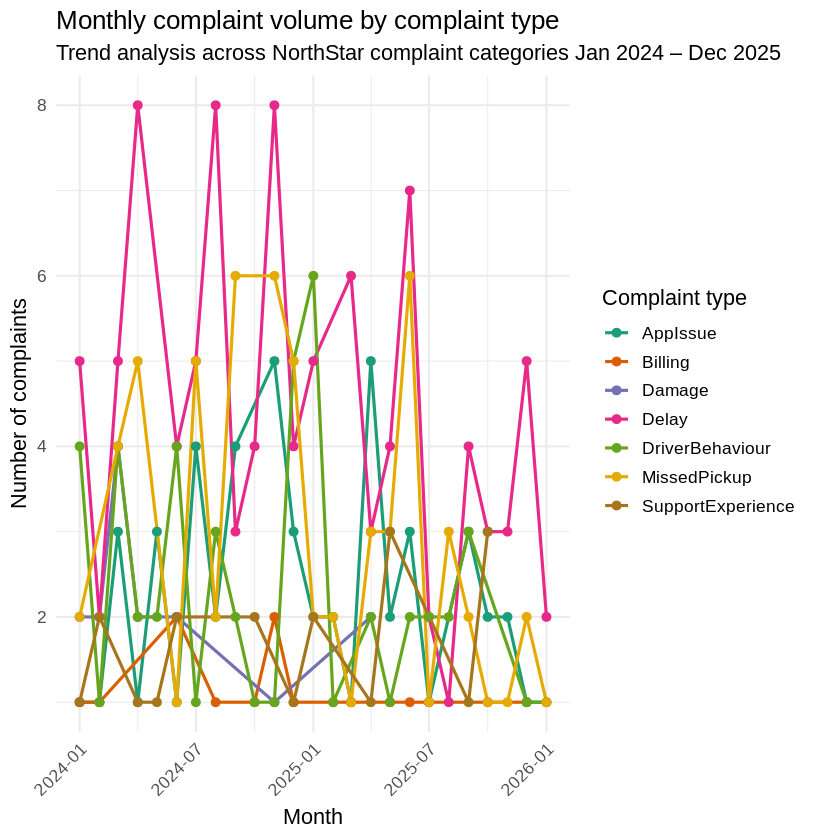

In [40]:
complaints$created_at <- ymd_hms(complaints$created_at)
complaints$month      <- floor_date(complaints$created_at, "month")

complaint_trend <- complaints %>%
  group_by(month, complaint_type) %>%
  summarise(count = n(), .groups = "drop")

ggplot(complaint_trend, aes(x = month, y = count,
                             colour = complaint_type,
                             group  = complaint_type)) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2) +
  scale_colour_brewer(palette = "Dark2") +
  labs(
    title    = "Monthly complaint volume by complaint type",
    subtitle = "Trend analysis across NorthStar complaint categories Jan 2024 – Dec 2025",
    x        = "Month",
    y        = "Number of complaints",
    colour   = "Complaint type"
  ) +
  theme_minimal(base_size = 13) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

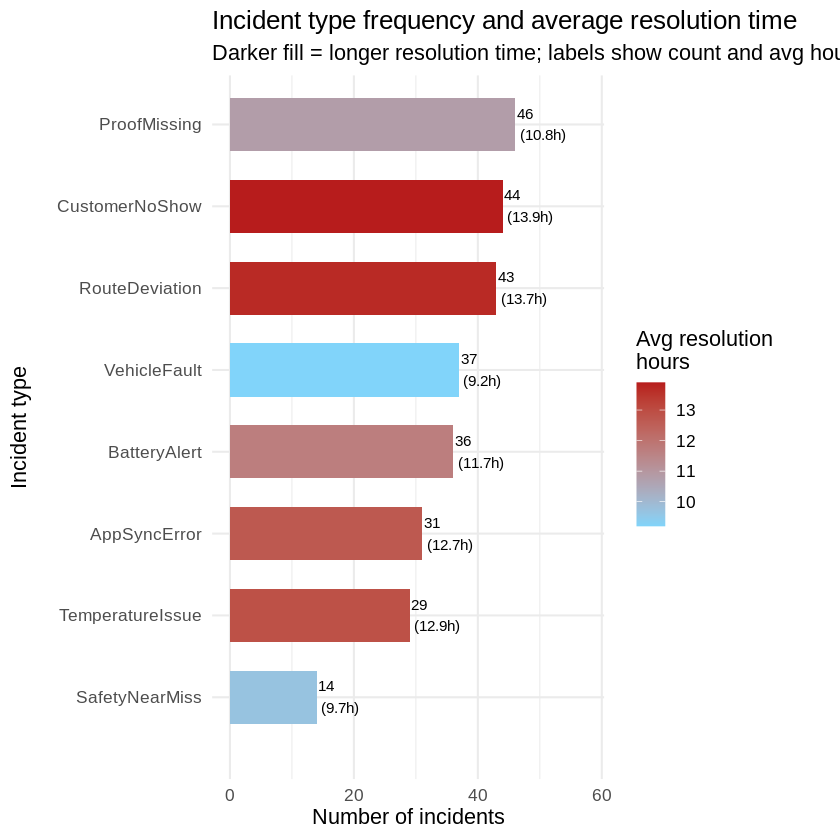

In [41]:
incident_summary <- incidents %>%
  group_by(incident_type) %>%
  summarise(
    count            = n(),
    avg_resolved_hrs = round(mean(resolved_hours, na.rm = TRUE), 1)
  ) %>%
  arrange(desc(count))

ggplot(incident_summary, aes(x = reorder(incident_type, count), y = count, fill = avg_resolved_hrs)) +
  geom_bar(stat = "identity", width = 0.65) +
  geom_text(aes(label = paste0(count, "\n(", avg_resolved_hrs, "h)")),
            hjust = -0.1, size = 3.2) +
  coord_flip() +
  scale_fill_gradient(low = "#81D4FA", high = "#B71C1C",
                      name = "Avg resolution\nhours") +
  labs(
    title    = "Incident type frequency and average resolution time",
    subtitle = "Darker fill = longer resolution time; labels show count and avg hours",
    x        = "Incident type",
    y        = "Number of incidents"
  ) +
  theme_minimal(base_size = 13) +
  expand_limits(x = c(0, NA), y = c(0, max(incident_summary$count) * 1.25))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plyr’




                              manual_route_override_count fuel_or_charge_cost
manual_route_override_count                         1.000               0.099
fuel_or_charge_cost                                 0.099               1.000
customer_rating_post_delivery                      -0.060              -0.057
route_distance_km                                   0.202               0.524
                              customer_rating_post_delivery route_distance_km
manual_route_override_count                          -0.060             0.202
fuel_or_charge_cost                                  -0.057             0.524
customer_rating_post_delivery                         1.000             0.029
route_distance_km                                     0.029             1.000


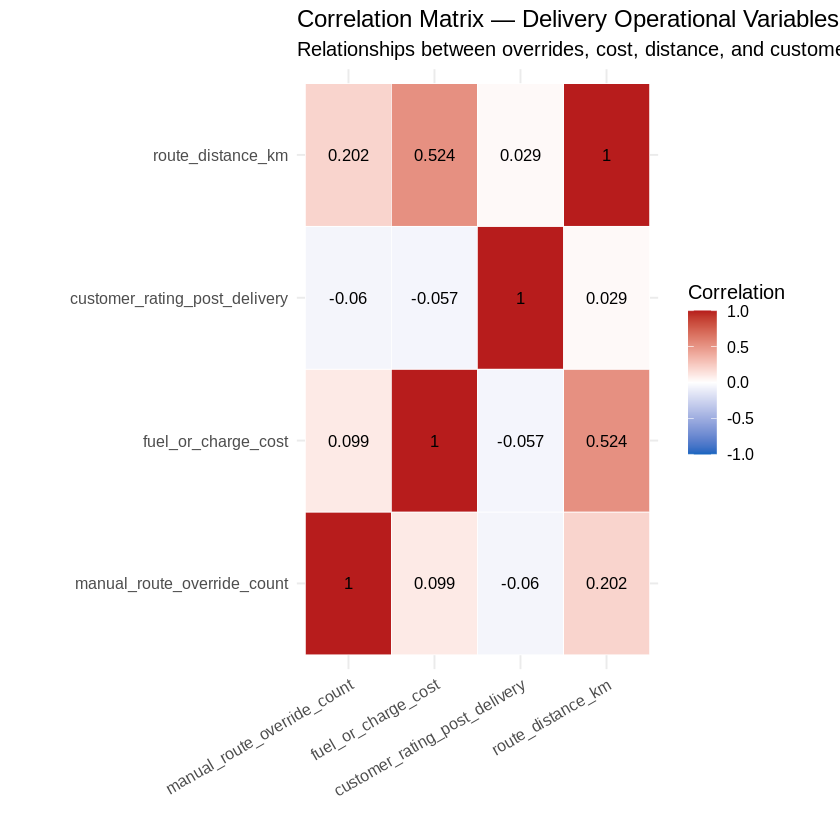

In [43]:
install.packages("reshape2")
library(dplyr)
library(ggplot2)
library(reshape2)

# Prepare data
cor_data <- deliveries %>%
  select(manual_route_override_count,
         fuel_or_charge_cost,
         customer_rating_post_delivery,
         route_distance_km) %>%
  filter(complete.cases(.))

# Correlation matrix
cor_matrix <- round(cor(cor_data), 3)
print(cor_matrix)

# Convert to long format
cor_melted <- melt(cor_matrix)

# Plot heatmap
ggplot(cor_melted, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(color = "white") +
  geom_text(aes(label = value), size = 3.5) +
  scale_fill_gradient2(low = "#1565C0", mid = "white", high = "#B71C1C",
                       midpoint = 0, limits = c(-1, 1),
                       name = "Correlation") +
  labs(
    title    = "Correlation Matrix — Delivery Operational Variables",
    subtitle = "Relationships between overrides, cost, distance, and customer rating",
    x = NULL, y = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))